In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
# 1. Load the Diabetes dataset as a Pandas DataFrame.
diabetes=load_diabetes(as_frame=True)
df=diabetes.frame

# 2. Display the first five rows of the dataset.
df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [17]:
df.shape


(442, 11)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [20]:
X_single = df[['bmi']]
y = df['target']

In [21]:
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_single, y, test_size=0.2, random_state=42
)

In [22]:
model_single = LinearRegression()
model_single.fit(X_train_s, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
print("--- Simple Linear Regression Results (BMI) ---")
print(f"Slope (Coefficient): {model_single.coef_[0]:.4f}")
print(f"Intercept: {model_single.intercept_:.4f}\n")

--- Simple Linear Regression Results (BMI) ---
Slope (Coefficient): 998.5777
Intercept: 152.0034



In [24]:
y_pred_s = model_single.predict(X_test_s)

In [25]:
mse_s = mean_squared_error(y_test, y_pred_s)
r2_s = r2_score(y_test, y_pred_s)
print(f"Mean Squared Error (MSE): {mse_s:.4f}")
print(f"R2 Score: {r2_s:.4f}\n")

Mean Squared Error (MSE): 4061.8259
R2 Score: 0.2334



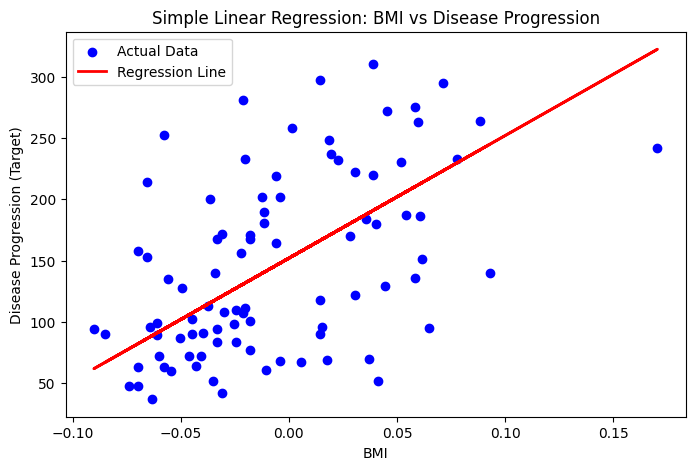

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test_s, y_test, color='blue', label='Actual Data')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: BMI vs Disease Progression')
plt.xlabel('BMI')
plt.ylabel('Disease Progression (Target)')
plt.legend()
plt.show()

In [28]:
bmi_val = pd.DataFrame({'bmi': [0.05]})
pred_progression = model_single.predict(bmi_val)
print(f"Predicted disease progression for BMI = 0.05: {pred_progression[0]:.4f}\n")

Predicted disease progression for BMI = 0.05: 201.9322



In [31]:
#REPEATING 

X_multi = df[['age', 'bmi', 'bp', 's1']]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

In [32]:
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
print("Coefficients for ['age', 'bmi', 'bp', 's1']:")
for feature, coef in zip(X_multi.columns, model_multi.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"Intercept: {model_multi.intercept_:.4f}\n")

Coefficients for ['age', 'bmi', 'bp', 's1']:
  age: 48.3174
  bmi: 836.0403
  bp: 380.1696
  s1: 0.3807
Intercept: 151.7676



In [34]:
y_pred_m = model_multi.predict(X_test_m)
mse_m = mean_squared_error(y_test_m, y_pred_m)
r2_m = r2_score(y_test_m, y_pred_m)

print(f"Multiple Linear Regression MSE: {mse_m:.4f}")
print(f"Multiple Linear Regression R2 Score: {r2_m:.4f}")

Multiple Linear Regression MSE: 3756.4507
Multiple Linear Regression R2 Score: 0.2910
